# HAR TFM

In [1]:
import pandas as pd
import numpy as np
import json

import math

import seaborn as sns
import matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline

from sklearn import metrics

ruta_archivo_csv = "Datos Combinados/data/DatosCombinados_Total.csv"

df = pd.read_csv(ruta_archivo_csv)
print(df)


              Gy        Gz          deviceId        Az  Lilluminance  \
0      -0.340853  0.260450  d99f0327fa491f9f  0.775127       19857.0   
1      -0.480737 -0.362767  d99f0327fa491f9f  0.954223           NaN   
2      -0.496084 -0.428662  d99f0327fa491f9f  0.820999           NaN   
3      -0.291909 -0.541592  d99f0327fa491f9f  0.966667           NaN   
4      -0.090405 -0.430266  d99f0327fa491f9f  0.834419           NaN   
...          ...       ...               ...       ...           ...   
136977       NaN       NaN  c32bdcc96f9e1fb1       NaN         119.0   
136978       NaN       NaN  c32bdcc96f9e1fb1       NaN        1068.0   
136979       NaN       NaN  c32bdcc96f9e1fb1       NaN         253.0   
136980       NaN       NaN  c32bdcc96f9e1fb1       NaN         240.0   
136981       NaN       NaN  5a287c6d3ffda73f       NaN       12163.0   

              Ax        Ay        Gx   Bpressure       Mx         My  \
0      -0.158082  0.531950 -0.111403  915.505005  0.56250 -45.3

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136982 entries, 0 to 136981
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Gy            132663 non-null  float64
 1   Gz            132663 non-null  float64
 2   deviceId      22049 non-null   object 
 3   Az            135287 non-null  float64
 4   Lilluminance  6691 non-null    float64
 5   Ax            135287 non-null  float64
 6   Ay            135287 non-null  float64
 7   Gx            132663 non-null  float64
 8   Bpressure     6552 non-null    float64
 9   Mx            132193 non-null  float64
 10  My            132193 non-null  float64
 11  activity      136982 non-null  int64  
 12  Mz            132193 non-null  float64
 13  counter       136982 non-null  int64  
 14  timestamp     136952 non-null  object 
dtypes: float64(11), int64(2), object(2)
memory usage: 15.7+ MB


## Reorganizar las columnas del csv. 

In [3]:
columnas_deseadas = ["Ax", "Ay", "Az", "Gx", "Gy", "Gz", "Mx", "My", "Mz", "Bpressure", "Lilluminance", "timestamp", "counter","deviceId", "activity"]  # Cambia los nombres de las columnas según tus necesidades
df = df.reindex(columns=columnas_deseadas)


## Ordenar los datos.

In [4]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.158082,0.531950,0.775127,-0.111403,-0.340853,0.260450,0.56250,-45.337502,-5.456250,915.505005,19857.0,2023-06-11 09:54:24,0,d99f0327fa491f9f,1
1,-0.077317,0.495350,0.954223,-0.521053,-0.480737,-0.362767,NaN,NaN,NaN,915.512451,NaN,2023-06-11 09:54:24,1,d99f0327fa491f9f,1
2,-0.004362,0.585874,0.820999,-0.099644,-0.496084,-0.428662,-0.90000,-45.900002,-9.018750,915.538757,NaN,2023-06-11 09:54:25,0,d99f0327fa491f9f,1
3,0.050783,0.535123,0.966667,-0.148436,-0.291909,-0.541592,-0.20625,-45.712502,-12.018750,915.567505,NaN,2023-06-11 09:54:25,1,d99f0327fa491f9f,1
4,0.053467,0.418979,0.834419,-0.027564,-0.090405,-0.430266,0.78750,-45.393753,-12.825001,915.552490,NaN,2023-06-11 09:54:25,2,d99f0327fa491f9f,1


In [5]:
df = df.sort_values(by=["timestamp", "counter"])
df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
134052,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
134053,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
134054,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
134055,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
134056,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
134057,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
134058,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
134059,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
134060,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
134061,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


## Comprobación de datos nulos y no nulos para cada persona

In [6]:
# Replace null values in 'deviceId' column with an invented value (e.g., "UNKNOWN_DEVICE")
invented_device_id = "UNKNOWN_DEVICE"
df['deviceId'] = df['deviceId'].fillna(invented_device_id)

In [7]:
# Agrupar por la columna "deviceId" y calcular el número de datos no nulos por columna
counts = df.groupby("deviceId").count()

# Calcular la suma de valores nulos por columna
null_counts = df.groupby("deviceId").apply(lambda x: x.isnull().sum())

# Mostrar el número de datos no nulos
counts.head(20)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,activity
deviceId,,,,,,,,,,,,,,
5a287c6d3ffda73f,1112,1112,1112,1045,1045,1045,1059,1059,1059,1052,1031,1181,1184,1184
629b502066d8a33a,220,220,220,157,157,157,157,157,157,0,194,235,235,235
73d32f5bb75976e4,1098,1098,1098,1058,1058,1058,1091,1091,1091,0,976,1139,1144,1144
8fe3a65e2ea6658d,9965,9965,9965,9363,9363,9363,9454,9454,9454,0,0,10340,10346,10346
UNKNOWN_DEVICE,114250,114250,114250,113013,113013,113013,113092,113092,113092,0,0,114927,114933,114933
b719b9175e5338b9,385,385,385,409,409,409,304,304,304,0,177,469,472,472
b973ac361183cbb0,616,616,616,555,555,555,591,591,591,0,461,693,693,693
bebf6a9bfd30c163,695,695,695,664,664,664,674,674,674,0,668,741,742,742
c32bdcc96f9e1fb1,768,768,768,746,746,746,576,576,576,0,460,839,842,842


In [8]:
# Mostrar el número de datos nulos
null_counts.head(20)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
deviceId,,,,,,,,,,,,,,,
5a287c6d3ffda73f,72,72,72,139,139,139,125,125,125,132,153,3,0,0,0
629b502066d8a33a,15,15,15,78,78,78,78,78,78,235,41,0,0,0,0
73d32f5bb75976e4,46,46,46,86,86,86,53,53,53,1144,168,5,0,0,0
8fe3a65e2ea6658d,381,381,381,983,983,983,892,892,892,10346,10346,6,0,0,0
UNKNOWN_DEVICE,683,683,683,1920,1920,1920,1841,1841,1841,114933,114933,6,0,0,0
b719b9175e5338b9,87,87,87,63,63,63,168,168,168,472,295,3,0,0,0
b973ac361183cbb0,77,77,77,138,138,138,102,102,102,693,232,0,0,0,0
bebf6a9bfd30c163,47,47,47,78,78,78,68,68,68,742,74,1,0,0,0
c32bdcc96f9e1fb1,74,74,74,96,96,96,266,266,266,842,382,3,0,0,0


## Selección de persona para analizar los datos

In [9]:
# Especificar el deviceId que deseas seleccionar
device_id = '8fe3a65e2ea6658d'

# Filtrar el DataFrame por el deviceId específico
device_data = df[df['deviceId'] == device_id]

## Comprobar si una de las columnas solo tiene valores nulos

In [10]:
# Verificar si alguna columna tiene solo valores no nulos
columnas_no_null = df.notnull().all()
print(columnas_no_null)

Ax              False
Ay              False
Az              False
Gx              False
Gy              False
Gz              False
Mx              False
My              False
Mz              False
Bpressure       False
Lilluminance    False
timestamp       False
counter          True
deviceId         True
activity         True
dtype: bool


## Comprobación de las columnas del sensor Acelerómetro

In [11]:
cantidad_nulos = df[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    1695
Ay    1695
Az    1695
dtype: int64


In [12]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Resetear el índice del DataFrame antes de aplicar la interpolación
df.reset_index(drop=True, inplace=True)

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Ax', 'Ay', 'Az']] = grouped[['Ax', 'Ay', 'Az']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


In [13]:
cantidad_nulos = df[['Ax', 'Ay', 'Az']].isnull().sum()
print(cantidad_nulos)

Ax    0
Ay    0
Az    0
dtype: int64


## Comprobación de las columnas del sensor Giroscopio

In [14]:
cantidad_nulos = df[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    4319
Gy    4319
Gz    4319
dtype: int64


In [15]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Gx', 'Gy', 'Gz']] = grouped[['Gx', 'Gy', 'Gz']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


In [16]:
cantidad_nulos = df[['Gx', 'Gy', 'Gz']].isnull().sum()
print(cantidad_nulos)

Gx    0
Gy    0
Gz    0
dtype: int64


## Comprobación de las columnas del sensor Magnetrómetro

In [17]:
cantidad_nulos = df[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    4789
My    4789
Mz    4789
dtype: int64


In [18]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Mx', 'My', 'Mz']] = grouped[['Mx', 'My', 'Mz']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,NaN,NaN,2023-06-04 17:36:20,0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,NaN,NaN,2023-06-04 17:36:20,1,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,NaN,NaN,2023-06-04 17:36:21,0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,NaN,NaN,2023-06-04 17:36:21,1,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,NaN,NaN,2023-06-04 17:36:21,2,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,NaN,NaN,2023-06-04 17:36:21,3,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,NaN,NaN,2023-06-04 17:36:22,0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,NaN,NaN,2023-06-04 17:36:22,1,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,NaN,NaN,2023-06-04 17:37:08,0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,NaN,NaN,2023-06-04 17:37:09,0,8fe3a65e2ea6658d,5


In [19]:
cantidad_nulos = df[['Mx', 'My', 'Mz']].isnull().sum()
print(cantidad_nulos)

Mx    0
My    0
Mz    0
dtype: int64


## Comprobación de la columna timestamp

In [20]:
cantidad_nulos = df[['timestamp']].isnull().sum()
print(cantidad_nulos)

timestamp    30
dtype: int64


In [21]:
# Convertir la columna 'timestamp' a tipo datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Obtener el timestamp en minutos desde la época (1970-01-01 00:00:00)
df['timestamp'] = df['timestamp'].astype(int) // (10**9 * 60)

# Verificar los cambios
print(df['timestamp'])

0          28098336
1          28098336
2          28098336
3          28098336
4          28098336
            ...    
136977   -153722868
136978   -153722868
136979   -153722868
136980   -153722868
136981   -153722868
Name: timestamp, Length: 136982, dtype: int64


/tmp/ipykernel_9624/1046296482.py:5: FutureWarning: casting datetime64[ns] values to int64 with .astype(...) is deprecated and will raise in a future version. Use .view(...) instead.
  df['timestamp'] = df['timestamp'].astype(int) // (10**9 * 60)


In [22]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['timestamp']] = grouped[['timestamp']].apply(lambda x: x.interpolate().fillna(method='bfill'))

In [23]:
cantidad_nulos = df[['timestamp']].isnull().sum()
print(cantidad_nulos)

timestamp    0
dtype: int64


## Comprobación de los sensores Barómetro y Luminancia

In [24]:
cantidad_nulos = df[['Bpressure', 'Lilluminance']].isnull().sum()
print(cantidad_nulos)

Bpressure       130430
Lilluminance    130291
dtype: int64


In [25]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['Bpressure', 'Lilluminance']] = grouped[['Bpressure', 'Lilluminance']].apply(lambda x: x.interpolate().fillna(method='bfill'))

df.head(40)

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.368750,8.156250,-24.168751,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.443750,8.193750,-24.300001,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.131250,8.212501,-23.943750,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.837500,8.400001,-23.400002,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.618750,8.100000,-23.025002,943.964355,85.940033,28098336,2,8fe3a65e2ea6658d,5
5,-0.166530,0.356850,0.921710,1.096242,1.998692,-3.054924,5.775000,9.093750,-21.675001,943.964355,85.940033,28098336,3,8fe3a65e2ea6658d,5
6,-0.132614,-0.420412,0.089426,0.723854,0.975218,-2.067413,4.556250,11.250000,-20.850000,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
7,-1.266848,-1.863428,0.959774,0.106516,0.042301,0.037185,-1.668750,-36.131252,-12.037500,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
8,0.098576,0.135542,0.964410,-0.911002,0.562132,0.792269,-2.362500,-34.912502,-12.937501,943.964355,85.940033,28098337,0,8fe3a65e2ea6658d,5
9,0.017324,0.217526,0.867298,1.332487,-0.786237,-0.487838,-2.587500,-33.937500,-13.387501,943.964355,85.940033,28098337,0,8fe3a65e2ea6658d,5


In [26]:
cantidad_nulos = df[['Bpressure', 'Lilluminance']].isnull().sum()
print(cantidad_nulos)

Bpressure       0
Lilluminance    0
dtype: int64


In [27]:
# Guardar los datos en un archivo CSV
df.to_csv('Dataset/HAR_TFM.csv', index=False)

In [28]:
# Agrupar por 'activity'
grouped = df.groupby('activity')

# Rellenar los valores nulos con la media entre el valor anterior y posterior
df[['counter']] = grouped[['counter']].apply(lambda x: x.interpolate().fillna(method='bfill'))

### Ajuste de columnas 

In [29]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

1    33320
3    29184
4    24424
6    20688
5    15011
2    14355
Name: activity, dtype: int64


In [30]:
# Eliminar las filas con los valores 3 y 6 en la columna 'activity'
#df = df.drop(df[(df['activity'] == 3) | (df['activity'] == 1)].index)
#df = df.drop(df[df['activity'] == 1].index)

In [31]:
df['activity'] = df['activity'].astype(int)
df['counter'] = df['counter'].astype(int)

#### Submuestreo y sobremuestreo de los valores

In [32]:
#import pandas as pd
#from sklearn.utils import resample

# Muestra la distribución actual de clases
#print(df['activity'].value_counts())

# Separar en diferentes DataFrames para cada clase
#df_classes = [df[df['activity'] == i] for i in df['activity'].unique()]

# Obtener la cantidad de datos de la clase mayoritaria
#max_samples = max([len(df_class) for df_class in df_classes])

# Realizar el submuestreo y sobremuestreo para cada clase
#df_balanced = []
#for df_class in df_classes:
#    df_class_upsampled = resample(df_class, replace=True, n_samples=max_samples, random_state=123)
#    df_balanced.append(df_class_upsampled)

# Combinar todos los DataFrames balanceados para formar el DataFrame final
#df = pd.concat(df_balanced)

In [33]:
# Contar la cantidad de ocurrencias de cada valor en la columna 'activity'
conteo_valores = df['activity'].value_counts()

# Imprimir el resultado
print(conteo_valores)

1    33320
3    29184
4    24424
6    20688
5    15011
2    14355
Name: activity, dtype: int64


In [34]:
df.head()

,Ax,Ay,Az,Gx,Gy,Gz,Mx,My,Mz,Bpressure,Lilluminance,timestamp,counter,deviceId,activity
0,-0.097234,0.418460,0.843996,0.286335,0.070782,0.084450,-1.36875,8.156250,-24.168751,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
1,0.249002,0.293410,1.201944,-0.177069,0.058947,0.357040,-1.44375,8.193750,-24.300001,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
2,0.240584,0.380152,1.015406,-0.172335,1.051955,0.423623,0.13125,8.212501,-23.943750,943.964355,85.940033,28098336,0,8fe3a65e2ea6658d,5
3,0.113704,0.335500,0.834236,-0.159355,0.307867,0.560376,1.83750,8.400001,-23.400002,943.964355,85.940033,28098336,1,8fe3a65e2ea6658d,5
4,0.038308,0.284992,0.928786,0.300766,0.246171,0.454623,3.61875,8.100000,-23.025002,943.964355,85.940033,28098336,2,8fe3a65e2ea6658d,5


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136982 entries, 0 to 136981
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Ax            136982 non-null  float64
 1   Ay            136982 non-null  float64
 2   Az            136982 non-null  float64
 3   Gx            136982 non-null  float64
 4   Gy            136982 non-null  float64
 5   Gz            136982 non-null  float64
 6   Mx            136982 non-null  float64
 7   My            136982 non-null  float64
 8   Mz            136982 non-null  float64
 9   Bpressure     136982 non-null  float64
 10  Lilluminance  136982 non-null  float64
 11  timestamp     136982 non-null  int64  
 12  counter       136982 non-null  int64  
 13  deviceId      136982 non-null  object 
 14  activity      136982 non-null  int64  
dtypes: float64(11), int64(3), object(1)
memory usage: 15.7+ MB


# Correlación de datos

In [36]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity        1.000000
Az              0.363840
Ay              0.198321
Bpressure       0.159290
Lilluminance    0.145918
My              0.063440
Mx              0.039966
counter         0.031026
Gz              0.030752
Gy              0.011938
Ax              0.005027
Gx              0.004693
timestamp       0.002316
Mz              0.000418
Name: activity, dtype: float64


## Matríz de correlación

Text(0.5, 1.0, 'Correlation Matrix')

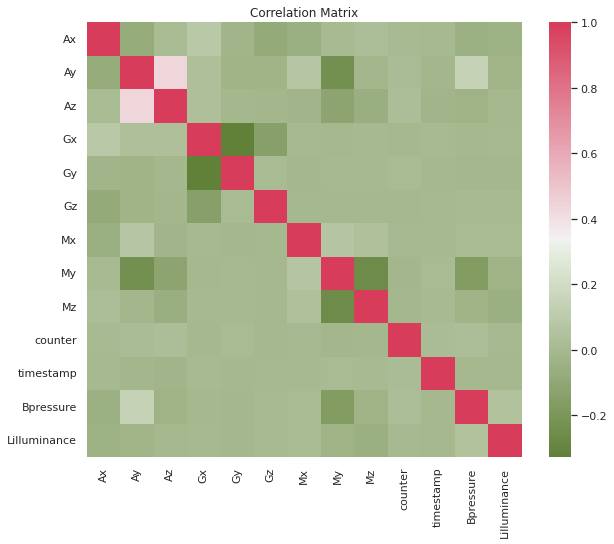

In [37]:
# Correlation matrix
CorrInfo = pd.DataFrame(df,columns=["Ax","Ay","Az","Gx","Gy","Gz","Mx","My","Mz","counter", "timestamp", 'Bpressure', 'Lilluminance'])

f, ax = plt.subplots(figsize=(10, 8))
corr = CorrInfo.corr()
sns.heatmap(corr, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(110, 5, as_cmap=True),
            square=True, ax=ax)
plt.title("Correlation Matrix")

In [38]:
#Square root of sum of squares of accelerometer, linear acceleration and gyroscope data
df["AxMy"] = np.sqrt(np.square(df['Ax']) + np.square(df['My']))
df["AxGy"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gy']))
df["Ayz"] = np.sqrt(np.square(df['Ay']) + np.square(df['Az']))
df["AxGx"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gx']))
df["AxGy"] = np.sqrt(np.square(df['Ax']) + np.square(df['Gy']))
df["AyGx"] = np.sqrt(np.square(df['Ay']) + np.square(df['Gx']))
df["AyGy"] = np.sqrt(np.square(df['Ay']) + np.square(df['Gy']))
df["AyMy"] = np.sqrt(np.square(df['Ay']) + np.square(df['My']))
df["AyMx"] = np.sqrt(np.square(df['Ay']) + np.square(df['Mx']))
df["AyMz"] = np.sqrt(np.square(df['Ay']) + np.square(df['Mz']))
df["AzGx"] = np.sqrt(np.square(df['Az']) + np.square(df['Gx']))
df["AzMx"] = np.sqrt(np.square(df['Az']) + np.square(df['Mx']))
df["Gzy"] = np.sqrt(np.square(df['Gz']) + np.square(df['Gy']) )
df["MxGy"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gy']) )
df["MxGx"] = np.sqrt(np.square(df['Mx']) + np.square(df['Gx']) )
df["MyGy"] = np.sqrt(np.square(df['My']) + np.square(df['Gy']) )
df["MyGx"] = np.sqrt(np.square(df['My']) + np.square(df['Gx']) )
df["Myz"] = np.sqrt(np.square(df['My']) + np.square(df['Mz']))
df["Mxz"] = np.sqrt(np.square(df['Mx']) + np.square(df['Mz']))
df["Mxy"] = np.sqrt(np.square(df['Mx']) + np.square(df['My']))

In [39]:
# Calcular el valor absoluto de la correlación entre todas las columnas y la columna "target"
correlations = abs(df.corr()['activity'])

# Ordenar las correlaciones de mayor a menor
correlations = correlations.sort_values(ascending=False)

# Visualizar las correlaciones
print(correlations)

activity        1.000000
AyGx            0.380974
Az              0.363840
AxGx            0.348600
AyGy            0.299349
AxGy            0.201563
Ay              0.198321
AzGx            0.192424
Gzy             0.161097
Bpressure       0.159290
Lilluminance    0.145918
Ayz             0.130764
My              0.063440
Mx              0.039966
AyMz            0.037819
counter         0.031026
Gz              0.030752
Myz             0.028915
Mxz             0.018263
AxMy            0.015231
MyGy            0.015162
AyMy            0.015014
MyGx            0.014990
Gy              0.011938
Mxy             0.007663
Ax              0.005027
Gx              0.004693
timestamp       0.002316
AzMx            0.001946
MxGy            0.001750
AyMx            0.001614
MxGx            0.001458
Mz              0.000418
Name: activity, dtype: float64


# Modelo de red neuronal

In [40]:
features = ['Az', 'AyGx','AxGx','AyGy','AxGy','AxGy','AzGx','Mxz','MyGx','AyMz','Ayz','Mz','Ax','My','Gzy','Ay','MxGx','MxGy','Myz','Mx','AyMx','AzMx','Gz']

In [41]:
#Para ver la mayor corelación
#features = ['AyGx', 'AyGy', 'Myz', 'Ayz', 'Mxy', 'Gzy', 'AyMz', 'MyGy', 'AyMy', 'MyGx', 'Mxz', 'AxMy', 'Az', 'Mx', 'AxGx', 'Mz', 'AxGy', 'MxGx', 'AzGx']
X_orig = df[features]
y = df['activity']

RANDOM_STATE = 10
numero_de_filas, numero_de_columnas = X_orig.shape

print("Número de filas:", numero_de_filas)
print("Número de columnas:", numero_de_columnas)

Número de filas: 136982
Número de columnas: 23


In [42]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Dropout

# Paso 1: Definir los datos de entrada y las etiquetas
X_orig = df[features]
y = df['activity']

# Paso 2: Separar características y variable objetivo
X = X_orig.to_numpy()

# Paso 3: Codificar etiquetas con LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Paso 4: Codificar etiquetas en formato one-hot
onehot_encoder = OneHotEncoder(sparse=False)
y_onehot = onehot_encoder.fit_transform(y_encoded.reshape(-1, 1))

# Paso 5: Dividir datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# Paso 6: Ajustar forma de los datos para LSTM y convertir a tipo float
X_train = X_train.astype(float)
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = X_test.astype(float)
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Paso 7: Crear modelo LSTM
model = Sequential()
#model.add(LSTM(256, input_shape=(1, X_train.shape[2])))
#model.add(Dropout(0.2))
#model.add(Dense(6, activation='softmax'))
#--------------------------------------------
model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))
model.add(LSTM(128))
#model.add(Dropout(0.2))
model.add(Dense(6, activation='softmax'))
#--------------------------------------------
#model.add(LSTM(128, input_shape=(1, X_train.shape[2])))
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(LSTM(128))
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense
#model.add(Dense(6, activation='softmax'))
#------------------------------------------------
#model.add(LSTM(256, input_shape=(1, X_train.shape[2]), return_sequences=True))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la primera capa LSTM
#model.add(LSTM(128))
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la segunda capa LSTM
#model.add(Dense(64, activation='relu'))  # Capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la capa Dense adicional
#model.add(Dense(32, activation='relu'))  # Otra capa Dense adicional
#model.add(Dropout(0.2))  # Agregar Dropout con 20% de desactivación después de la otra capa Dense adicional
#model.add(Dense(6, activation='softmax'))


# Paso 8: Compilar y entrenar modelo LSTM
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=20, batch_size=64, validation_data=(X_test, y_test))


2023-10-02 15:57:54.953646: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-02 15:58:02.116545: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-10-02 15:58:02.119336: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-02 15:58:18.071222: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
2023

Epoch 1/20


2023-10-02 15:58:40.146235: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-10-02 15:58:40.147400: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-10-02 15:58:40.148606: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1712/1713 [============================>.] - ETA: 0s - loss: 0.6705 - accuracy: 0.7621

2023-10-02 15:58:51.536862: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-10-02 15:58:51.537854: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-10-02 15:58:51.538904: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

1713/1713 [==============================] - 13s 6ms/step - loss: 0.6705 - accuracy: 0.7621 - val_loss: 0.5415 - val_accuracy: 0.8114
Epoch 2/20
1713/1713 [==============================] - 9s 5ms/step - loss: 0.5144 - accuracy: 0.8156 - val_loss: 0.5340 - val_accuracy: 0.8098
Epoch 3/20
1713/1713 [==============================] - 10s 6ms/step - loss: 0.4733 - accuracy: 0.8292 - val_loss: 0.4707 - val_accuracy: 0.8276
Epoch 4/20
1713/1713 [==============================] - 10s 6ms/step - loss: 0.4437 - accuracy: 0.8386 - val_loss: 0.4365 - val_accuracy: 0.8402
Epoch 5/20
1713/1713 [==============================] - 10s 6ms/step - loss: 0.4207 - accuracy: 0.8474 - val_loss: 0.4455 - val_accuracy: 0.8378
Epoch 6/20
1713/1713 [==============================] - 9s 5ms/step - loss: 0.4043 - accuracy: 0.8520 - val_loss: 0.4098 - val_accuracy: 0.8489
Epoch 7/20
1713/1713 [==============================] - 9s 6ms/step - loss: 0.3842 - accuracy: 0.8591 - val_loss: 0.3916 - val_accuracy: 0.8568

In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Realizar las predicciones en el conjunto de prueba
y_pred = model.predict(X_test)
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)

# Decodificar las etiquetas reales
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación
accuracy = np.mean(y_pred_labels_decoded == y_test_labels_decoded)
precision = precision_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
recall = recall_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')
f1 = f1_score(y_test_labels_decoded, y_pred_labels_decoded, average='weighted')

# Imprimir los resultados
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

2023-10-02 16:01:54.311850: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_2_grad/concat/split_2/split_dim' with dtype int32
	 [[{{node gradients/split_2_grad/concat/split_2/split_dim}}]]
2023-10-02 16:01:54.313021: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'gradients/split_grad/concat/split/split_dim' with dtype int32
	 [[{{node gradients/split_grad/concat/split/split_dim}}]]
2023-10-02 16:01:54.314054: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You mus

857/857 [==============================] - 2s 2ms/step
Accuracy: 0.8904624593933642
Precision: 0.8911053214925516
Recall: 0.8904624593933642
F1 Score: 0.8903085685159455


/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

# Realizar las predicciones en el conjunto de prueba
y_pred_probabilities = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# Decodificar las etiquetas predichas y reales
y_pred_labels_decoded = label_encoder.inverse_transform(y_pred_labels)
y_test_labels = onehot_encoder.inverse_transform(y_test)
y_test_labels_decoded = label_encoder.inverse_transform(y_test_labels)

# Calcular las métricas de evaluación para cada etiqueta
num_labels = len(label_encoder.classes_)
accuracy_per_label = []
precision_per_label = []
recall_per_label = []
f1_per_label = []

for label_idx in range(num_labels):
    y_true_label = (y_test_labels_decoded == label_encoder.classes_[label_idx]).astype(int)
    y_pred_label = (y_pred_labels_decoded == label_encoder.classes_[label_idx]).astype(int)

    accuracy_per_label.append(accuracy_score(y_true_label, y_pred_label))
    precision_per_label.append(precision_score(y_true_label, y_pred_label))
    recall_per_label.append(recall_score(y_true_label, y_pred_label))
    f1_per_label.append(f1_score(y_true_label, y_pred_label))

# Imprimir los resultados por etiqueta
for label_idx in range(num_labels):
    print(f'Label: {label_encoder.classes_[label_idx]}, {Labels[label_idx]}')
    print('Accuracy:', accuracy_per_label[label_idx])
    print('Precision:', precision_per_label[label_idx])
    print('Recall:', recall_per_label[label_idx])
    print('F1 Score:', f1_per_label[label_idx])
    print()

857/857 [==============================] - 1s 1ms/step
Label: 1, Caminar
Accuracy: 0.9282403182830237
Precision: 0.827745180217938
Recall: 0.8899068789426254
F1 Score: 0.8577012159814709

Label: 2, Metro
Accuracy: 0.974924261780487
Precision: 0.8836509528585758
Recall: 0.886317907444668
F1 Score: 0.8849824208940231

Label: 3, Bus
Accuracy: 0.9730992444428223
Precision: 0.9382286410301026
Recall: 0.9338413578108763
F1 Score: 0.9360298585192257

Label: 4, Conducir coche
Accuracy: 0.9922254261415483
Precision: 0.9841605068637803
Recall: 0.9712380158399333
F1 Score: 0.9776565614182313

Label: 5, Subir o bajar escaleras
Accuracy: 0.9375479067051137
Precision: 0.7370810055865922
Recall: 0.6878462039752362
F1 Score: 0.7116130119669644

Label: 6, Estar detenido
Accuracy: 0.9748877614337336
Precision: 0.9392619169656586
Recall: 0.890427599611273
F1 Score: 0.9141930656023947



/home/ricardo.casanova/.local/lib/python3.9/site-packages/sklearn/preprocessing/_label.py:155: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


## Matriz de confusión

<function matplotlib.pyplot.show(close=None, block=None)>

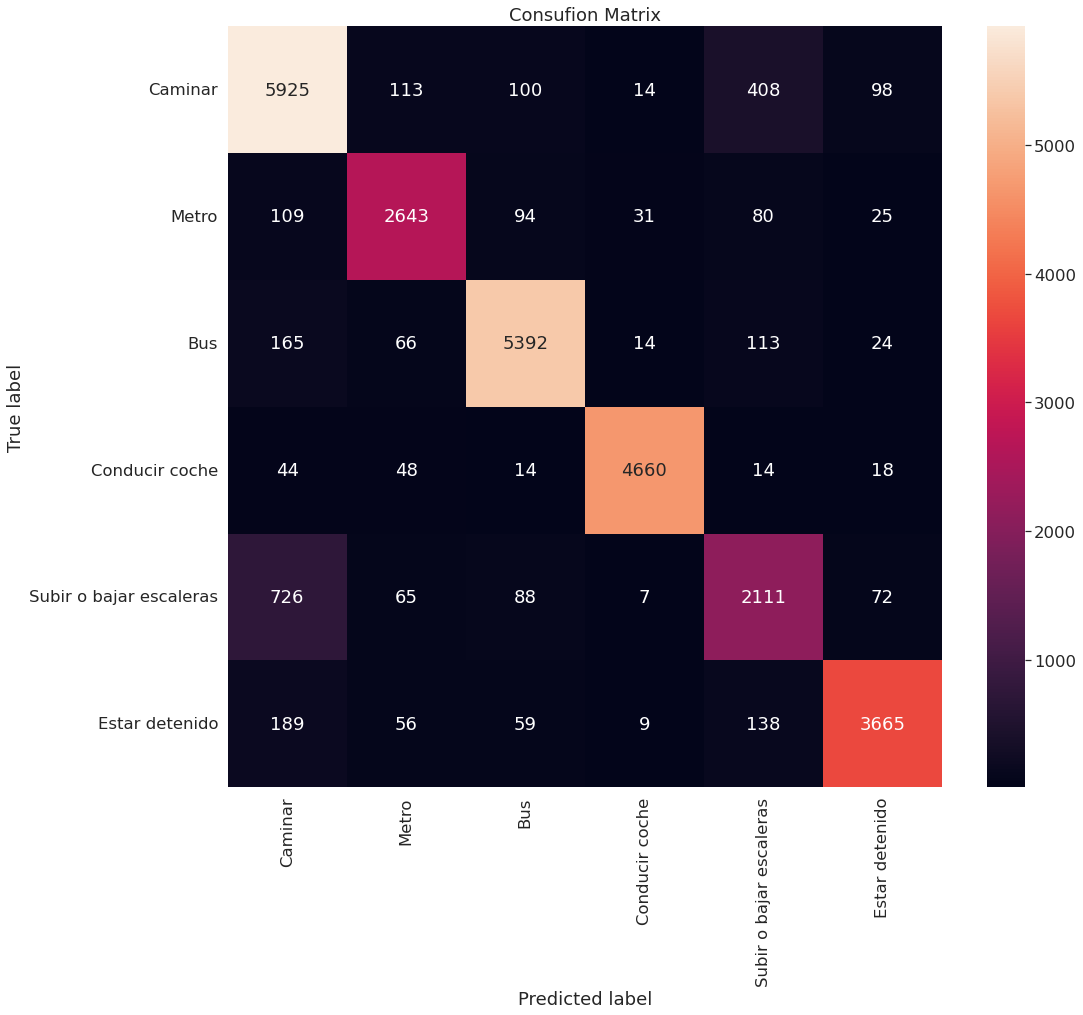

In [45]:
confusion_matrix = metrics.confusion_matrix(y_true=y_true_labels, y_pred=y_pred_labels)

#Labels=['Caminar', 'Metro', 'Conducir coche', 'Subir o bajar escaleras']
#Labels=['Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
Labels=['Caminar', 'Metro', 'Bus', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']
#Labels=['Metro', 'Conducir coche', 'Subir o bajar escaleras', 'Estar detenido']

plt.figure(figsize=(16,14))
sns.set(style='whitegrid', palette='muted', font_scale=1.5)
sns.heatmap(confusion_matrix, xticklabels=Labels, yticklabels=Labels, annot=True,fmt='d')
plt.title('Consufion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show


In [46]:
# Obtener los valores únicos y sus conteos
valores, conteos = np.unique(y_true_labels, return_counts=True)

#Imprimir el resultado
for valor, conteo, label in zip(valores, conteos, Labels):
    print(f"Valor: {valor}, Cantidad: {conteo}, Actividad: {label}")

Valor: 0, Cantidad: 6658, Actividad: Caminar
Valor: 1, Cantidad: 2982, Actividad: Metro
Valor: 2, Cantidad: 5774, Actividad: Bus
Valor: 3, Cantidad: 4798, Actividad: Conducir coche
Valor: 4, Cantidad: 3069, Actividad: Subir o bajar escaleras
Valor: 5, Cantidad: 4116, Actividad: Estar detenido
